# Aufgabe 4 – Packungsproblem

Aufgabe 4 (Packungsproblem) (40 %)
Ein Packungsproblem (hier 2-dimensional) besteht in der Aufgabe N kleinere Rechtecke in ein großes
Rechteck überschneidungsfrei zu platzieren. Ein Rechteck ist dabei ein n*m großes Quadratgitter.
Die Rechtecke werden entweder horizontal oder vertikal am Gitter ausgerichtet platziert.
Wie lässt sich das Packungsproblem ganz allgemein als CSP formulieren?
Lösen Sie das hier abgebildete Packungsproblem mit python_constraint.

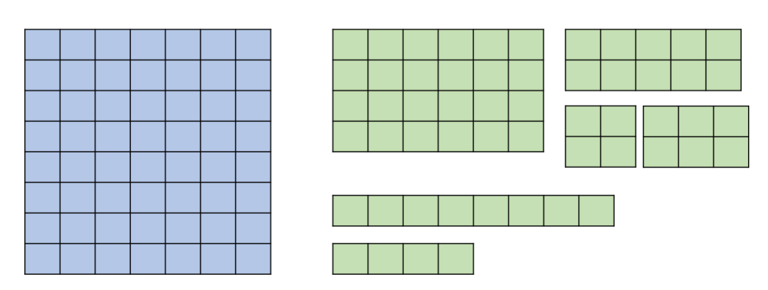

 Die N = 6 grünen Rechtecke (6*4, 8*1, 4*1, 5*2, 2*2 und 3*2) sollen in das blaue Rechteck (7*8) überschneidungsfrei platziert werden.

### 1. Definieren von 7 n*m matritzen


In [6]:
import numpy as np
from constraint import Problem

blue_7x8 = np.zeros((7,8))

green_6x4 = np.zeros((6,4))
green_8x1 = np.zeros((8,1))
green_4x1 = np.zeros((4,1))
green_5x2 = np.zeros((5,2))
green_3x2 = np.zeros((3,2))
green_2x2 = np.zeros((2,2))

# --- Früherer Ansatz (falsch) ---
# problem.addVariable(f"raster", [green_6x4, green_8x1, green_4x1, green_5x2, green_3x2, green_2x2])

# domain_6x4 = (
#     [(r, c, "h") for r in range(7 - 6 + 1) for c in range(8 - 4 + 1)] +
#     [(r, c, "v") for r in range(7 - 4 + 1) for c in range(8 - 6 + 1)]
# )
# problem.addVariable("green_6x4", domain_6x4)

# problem.addVariable("green6x4", [green_6x4, "h"])
# problem.addVariable("green4x1", [green_4x1, "h"])
#
# for r, c in blue_7x8:
#     problem.addConstraint(
#         lambda green6x4, green4x1: green6x4[0] != green4x1[0], ["green6x4", "green4x1"]
#     )
# --------------------------------

ROWS, COLS = 8, 7  # blaues Rechteck: 8 Zeilen × 7 Spalten

rectangles = {
    "green_6x4": (6, 4),
    "green_8x1": (8, 1),
    "green_4x1": (4, 1),
    "green_5x2": (5, 2),
    "green_3x2": (3, 2),
    "green_2x2": (2, 2),
}

def make_domain(h, w, rows=ROWS, cols=COLS):
    domain = []
    # horizontal: h Zeilen × w Spalten
    if h <= rows and w <= cols:
        domain += [(r, c, "h") for r in range(rows - h + 1) for c in range(cols - w + 1)]
    # vertikal: w Zeilen × h Spalten
    if h != w and w <= rows and h <= cols:
        domain += [(r, c, "v") for r in range(rows - w + 1) for c in range(cols - h + 1)]
    return domain

def no_overlap(p1, p2, dims1, dims2):
    r1, c1, o1 = p1
    r2, c2, o2 = p2
    h1, w1 = dims1 if o1 == "h" else (dims1[1], dims1[0])
    h2, w2 = dims2 if o2 == "h" else (dims2[1], dims2[0])
    return (r1 + h1 <= r2 or r2 + h2 <= r1 or
            c1 + w1 <= c2 or c2 + w2 <= c1)

problem = Problem()

for name, (h, w) in rectangles.items():
    problem.addVariable(name, make_domain(h, w))

# Nicht-Überlappungs-Constraint für jedes Paar (15 insgesamt)
names = list(rectangles.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        n1, n2 = names[i], names[j]
        d1, d2 = rectangles[n1], rectangles[n2]
        problem.addConstraint(
            lambda p1, p2, d1=d1, d2=d2: no_overlap(p1, p2, d1, d2),
            (n1, n2)
        )

solutions = problem.getSolutions()

def visualize_all(solution):
    grid = np.zeros((ROWS, COLS), dtype=int)
    for label, (name, (h, w)) in enumerate(rectangles.items(), 1):
        r, c, o = solution[name]
        rh, rw = (h, w) if o == "h" else (w, h)
        grid[r:r+rh, c:c+rw] = label
    return grid

def showSolution(solution, index):
    print(f"Solution {index}")
    print("--------")
    print(visualize_all(solution))
    print()

print(f"Found {len(solutions)} solution(s)!\n")
for i, solution in enumerate(solutions, 1):
    showSolution(solution, i)


Found 32 solution(s)!

Solution 1
--------
[[3 6 6 5 5 5 2]
 [3 6 6 5 5 5 2]
 [3 4 4 4 4 4 2]
 [3 4 4 4 4 4 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]]

Solution 2
--------
[[3 5 5 5 6 6 2]
 [3 5 5 5 6 6 2]
 [3 4 4 4 4 4 2]
 [3 4 4 4 4 4 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]]

Solution 3
--------
[[6 6 5 5 5 3 2]
 [6 6 5 5 5 3 2]
 [4 4 4 4 4 3 2]
 [4 4 4 4 4 3 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]]

Solution 4
--------
[[5 5 5 6 6 3 2]
 [5 5 5 6 6 3 2]
 [4 4 4 4 4 3 2]
 [4 4 4 4 4 3 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]]

Solution 5
--------
[[3 4 4 4 4 4 2]
 [3 4 4 4 4 4 2]
 [3 6 6 5 5 5 2]
 [3 6 6 5 5 5 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]]

Solution 6
--------
[[3 4 4 4 4 4 2]
 [3 4 4 4 4 4 2]
 [3 5 5 5 6 6 2]
 [3 5 5 5 6 6 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]
 [1 1 1 1 1 1 2]]

Solution 7
--------
[[4 4 4 4